In [1]:
print(1+1)

2


In [3]:
! pip install Math

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement Math (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for Math


In [5]:
import numpy as np
import math

L,d_k,d_v=4,8,8
q=np.random.randn(L,d_k)
k=np.random.randn(L,d_k)
v=np.random.randn(L,d_v)

In [6]:
print(q)

[[ 0.60562703 -0.40184061 -0.39152727 -0.44764138  0.22142042 -0.67680449
  -1.98359726  0.67708382]
 [-0.87737291 -0.65744198 -0.25037275 -0.31483058 -0.62327206 -1.17785288
   1.49022435 -0.18345142]
 [ 0.00592868 -0.31451612  0.81360373 -0.05151369 -2.86011493  0.21740564
  -0.58603779  0.8830375 ]
 [ 2.22280066 -0.8698176  -1.45068767 -1.38681815 -0.17294231 -2.04288574
  -0.84288753 -1.39954233]]


In [7]:
print(k)

[[-1.99110183 -0.46056819 -0.39414356  1.2022084  -1.0114545  -0.9350554
  -0.86011588 -0.71420231]
 [ 0.69751496  0.83466836 -0.19944933  0.46461545 -0.03328942 -0.44169761
   2.05639829 -0.67325251]
 [-0.05322346 -1.79288986  0.57045251  0.84093113  0.781364    0.46903206
  -0.09607917 -0.70497044]
 [ 0.03958273  0.73686293  0.67274929  0.38560725  0.28371378  0.8309573
   1.31329784 -0.47878673]]


In [8]:
print(v)

[[ 1.20457839 -0.71163112  0.24053387  1.24997477 -0.39258188 -2.07955738
   0.71813338  0.45596584]
 [ 0.12163869  0.47244202 -0.23109778  0.34241232  0.19267932  0.76471446
  -0.88773889  0.12558357]
 [-0.22268106  0.72367856  0.0746196  -0.04047286  0.46546885 -0.15334812
   0.46422845  0.56581248]
 [-0.93983772 -1.05219851  0.1293388  -1.49196066 -0.14787999 -2.09713037
   0.3380677   0.83896905]]


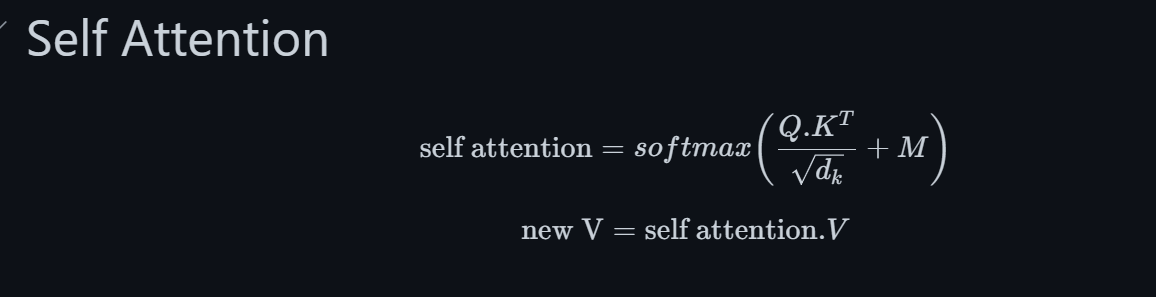

In [9]:
np.matmul(q,k.T)

array([[ 0.22681132, -4.2862034 , -0.34273564, -4.13695089],
       [ 2.35095133,  2.47194189, -0.23546352,  0.08035373],
       [ 2.31342746, -2.24503838, -1.7146499 , -1.52726134],
       [-1.31100547,  0.58645684, -0.57827486, -4.24716507]])

In [15]:
scaled=np.matmul(q,k.T)/math.sqrt(d_k)
scaled

array([[ 0.08018991, -1.51540175, -0.12117535, -1.46263301],
       [ 0.83118682,  0.87396344, -0.08324893,  0.02840933],
       [ 0.81792012, -0.79374093, -0.60622029, -0.53996842],
       [-0.46351043,  0.2073438 , -0.20445104, -1.50159961]])

## Masking

- This is to ensure words don't get context from words generated in the future. 
- Not required in the encoders, but required int he decoders

In [12]:
mask = np.tril(np.ones( (L, L) ))
mask

array([[1., 0., 0., 0.],
       [1., 1., 0., 0.],
       [1., 1., 1., 0.],
       [1., 1., 1., 1.]])

In [13]:
mask[mask == 0] = -np.infty
mask[mask == 1] = 0

In [16]:
scaled+mask

array([[ 0.08018991,        -inf,        -inf,        -inf],
       [ 0.83118682,  0.87396344,        -inf,        -inf],
       [ 0.81792012, -0.79374093, -0.60622029,        -inf],
       [-0.46351043,  0.2073438 , -0.20445104, -1.50159961]])

## SOFTMAX

In [17]:
def softmax(x):
  return (np.exp(x).T / np.sum(np.exp(x), axis=-1)).T

attention = softmax(scaled + mask)
attention

array([[1.        , 0.        , 0.        , 0.        ],
       [0.48930747, 0.51069253, 0.        , 0.        ],
       [0.6943137 , 0.13855437, 0.16713193, 0.        ],
       [0.21711996, 0.42466653, 0.28132466, 0.07688885]])

In [18]:
new_v = np.matmul(attention, v)
new_v

array([[ 1.20457839e+00, -7.11631116e-01,  2.40533869e-01,
         1.24997477e+00, -3.92581875e-01, -2.07955738e+00,
         7.18133376e-01,  4.55965843e-01],
       [ 6.51529182e-01, -1.06933818e-01, -3.24891255e-04,
         7.86489412e-01, -9.36933581e-02, -6.27009010e-01,
        -1.01973585e-01,  2.87242086e-01],
       [ 8.15991743e-01, -3.07686538e-01,  1.47457671e-01,
         9.08553029e-01, -1.68083708e-01, -1.36354002e+00,
         4.53197134e-01,  4.28548814e-01],
       [ 1.78285179e-01,  1.68807294e-01, -1.49777452e-02,
         2.90704376e-01,  1.16164644e-01, -3.31151312e-01,
        -6.44793592e-02,  3.76014791e-01]])

## Weighted Sum of Values

In [19]:
def softmax(x):
  return (np.exp(x).T / np.sum(np.exp(x), axis=-1)).T

def scaled_dot_product_attention(q, k, v, mask=None):
  d_k = q.shape[-1]
  scaled = np.matmul(q, k.T) / math.sqrt(d_k)
  if mask is not None:
    scaled = scaled + mask
  attention = softmax(scaled)
  out = np.matmul(attention, v)
  return out, attention

In [20]:
values, attention = scaled_dot_product_attention(q, k, v, mask=mask)
print("Q\n", q)
print("K\n", k)
print("V\n", v)
print("New V\n", values)
print("Attention\n", attention)

Q
 [[ 0.60562703 -0.40184061 -0.39152727 -0.44764138  0.22142042 -0.67680449
  -1.98359726  0.67708382]
 [-0.87737291 -0.65744198 -0.25037275 -0.31483058 -0.62327206 -1.17785288
   1.49022435 -0.18345142]
 [ 0.00592868 -0.31451612  0.81360373 -0.05151369 -2.86011493  0.21740564
  -0.58603779  0.8830375 ]
 [ 2.22280066 -0.8698176  -1.45068767 -1.38681815 -0.17294231 -2.04288574
  -0.84288753 -1.39954233]]
K
 [[-1.99110183 -0.46056819 -0.39414356  1.2022084  -1.0114545  -0.9350554
  -0.86011588 -0.71420231]
 [ 0.69751496  0.83466836 -0.19944933  0.46461545 -0.03328942 -0.44169761
   2.05639829 -0.67325251]
 [-0.05322346 -1.79288986  0.57045251  0.84093113  0.781364    0.46903206
  -0.09607917 -0.70497044]
 [ 0.03958273  0.73686293  0.67274929  0.38560725  0.28371378  0.8309573
   1.31329784 -0.47878673]]
V
 [[ 1.20457839 -0.71163112  0.24053387  1.24997477 -0.39258188 -2.07955738
   0.71813338  0.45596584]
 [ 0.12163869  0.47244202 -0.23109778  0.34241232  0.19267932  0.76471446
  -0.887